
#### Цель работы

Научиться применять модель дерева принятия решений для задач классификации и регрессии.

#### Содержание работы

1. Cгенерируйте данные для задачи классификации на три класса при помощи sklearn.datasets.make_blobs, содержащие два признака и 100 наблюдений. Визуализируйте их на диаграмме рассеяния.
1. Обучите модель классификационного решающего дерева sklearn.svm.DecisionTreeClassifier глубины 4 и критерием entropy.
1. Визуализируйте соответствующий граф дерева решений.
1. Визуализируйте полученные разделяющие области.
1. Оцените качество работы модели. Создайте новое наблюдение и сделайте предсказание на нём.
1. Cгенерируйте данные для задачи регрессии, содержащие один признак и 100 наблюдений, как случайный шум некоторой функции. Визуализируйте их на диаграмме рассеяния.
1. Обучите модель регрессионного решающего дерева sklearn.svm.DecisionTreeRegressor глубиной 3.
1. Визуализируйте соответствующий граф дерева решений.
1. Визуализируйте получившуюся кусочную линию регрессии.
1. Оцените качество работы модели. Создайте новое наблюдение и сделайте предсказание на нём.

#### Методические указания

##### Задача классификации

По аналогии с предыдущими работами, создадим и визуализируем датасет:

In [757]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
import sklearn.tree as tree
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, r2_score, mean_squared_error
from sklearn.tree import export_text

Text(0, 0.5, 'X2')

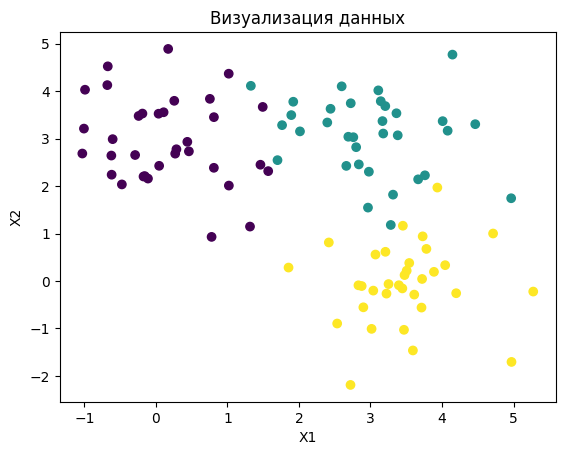

In [758]:
RANDOM_SEED = 1
X, y = make_blobs(n_samples=100, centers=[(0,3),(3,3),(3,0)], 
                                      n_features=2, random_state=RANDOM_SEED,
                                      cluster_std=(0.9,0.9,0.9))
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title('Визуализация данных')
plt.xlabel('X1')
plt.ylabel('X2')

Также, как и перцептрон, деревья решений могут легко применяться к задачам разной размерности. Количество классов не играет роли для дерева. Содадим и обучим модель:

In [759]:
depth=4
clf_tree = DecisionTreeClassifier(criterion='entropy', max_depth=depth, 
                                  random_state=RANDOM_SEED)
clf_tree.fit(X, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",1
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

Здесь мы задаем вид функции, которая будет использоваться для нахождения оптимальной границы разбиения выборки. По умолчанию используется критерий Джини, а мы сейчас будем использовать критерий информационной энтропии. Также мы задает максимальную глубину дерева. Дерево не будет "расти" дальше этого количества уровней. Вы самостоятельно можете изменить значения этих параметров и проанализировать, как это повлияет на рабоут модели.

После обучения данной модели мы можем вывести собственно само дерево решений, то есть полное внутреннее устройство модели. Для этого в объекте существует специальный метод plot_tree():

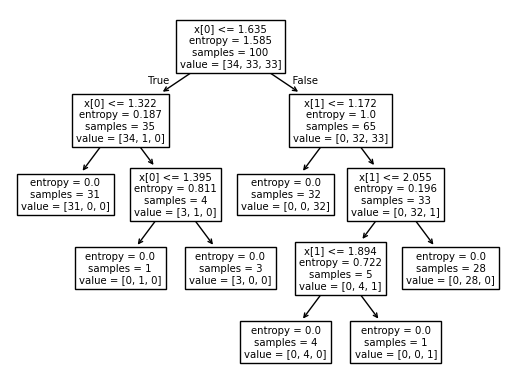

In [760]:
tree.plot_tree(clf_tree) 
plt.show()

В этом объекте есть еще один метод визуализации дерева - втекстовом виде. Самостоятельно найдите и примените его.

In [761]:
tree_text = export_text(clf_tree, feature_names=['X1', 'X2'])
print(tree_text)

|--- X1 <= 1.64
|   |--- X1 <= 1.32
|   |   |--- class: 0
|   |--- X1 >  1.32
|   |   |--- X1 <= 1.39
|   |   |   |--- class: 1
|   |   |--- X1 >  1.39
|   |   |   |--- class: 0
|--- X1 >  1.64
|   |--- X2 <= 1.17
|   |   |--- class: 2
|   |--- X2 >  1.17
|   |   |--- X2 <= 2.05
|   |   |   |--- X2 <= 1.89
|   |   |   |   |--- class: 1
|   |   |   |--- X2 >  1.89
|   |   |   |   |--- class: 2
|   |   |--- X2 >  2.05
|   |   |   |--- class: 1



Проинтерпретируйте изображенную на этом графике информацию.

Это дерево решений глубиной 4 обучено на 100 объектах трёх классов (≈34/33/33). Первое разбиение происходит по признаку X[0] ≤ 1.635, отделяя левую ветку (35 объектов) с почти чистыми классами 0 и правую ветку (65 объектов), где классы 1 и 2 дальше разделяются по X[1] с порогами 1.172, 2.055 и 1.894. В результате все листья стали чистыми (энтропия = 0), кроме одного с распределением [0,4,1]. Модель разделила три облака точек.

Теперь можно визуализировать сами границы принятия решений:

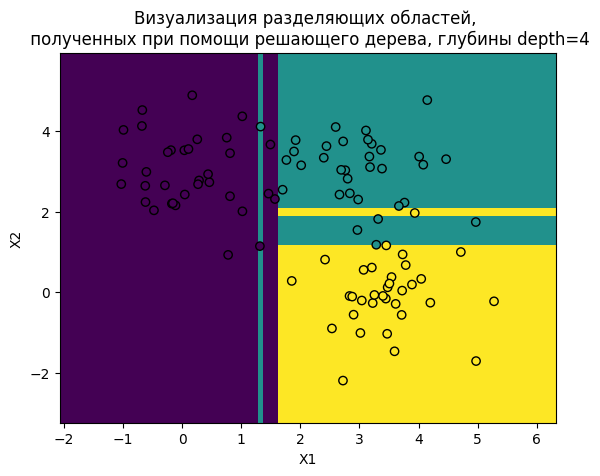

In [762]:
X0 = np.linspace(X[:, 0].min()-1,X[:, 0].max()+1, X.shape[0])
X1 = np.linspace(X[:, 1].min()-1,X[:, 1].max()+1, X.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

y_predict = clf_tree.predict(np.c_[X0_grid.ravel(),X1_grid.ravel()]).reshape(X0_grid.shape)
plt.pcolormesh(X0_grid, X1_grid, y_predict)

plt.scatter(X[:, 0], X[:, 1], c=y,  edgecolors='black',linewidth=1)

plt.title('Визуализация разделяющих областей, \n полученных при помощи решающего дерева, глубины depth={}'.format(depth))
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

Как всегда оценим качество работы модели и с помощью метрик:

In [763]:
y_pred = clf_tree.predict(X)
print(confusion_matrix(y, y_pred))
print('Accuracy =', accuracy_score(y, y_pred))
print('F1_score =', f1_score(y, y_pred, average='micro'))

[[34  0  0]
 [ 0 33  0]
 [ 0  0 33]]
Accuracy = 1.0
F1_score = 1.0


Мы видим, что модель допустила ноль ошибок на 100 примерах, что довольно хорошо. Если бы были ошибки мы бы могли увеличить точность увеличив глубину дерева и добиться абсолютной точности.

Теперь создадим новое наблюдение:

In [764]:
observation_new = [[2, 1]]

И классифицируем его:

In [765]:
clf_tree.predict(observation_new)

array([2])

Визуализируем на графике его вместе с границей принятия решений:

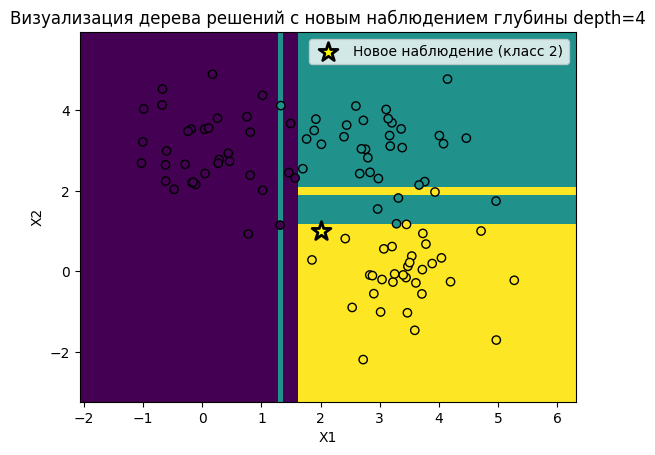

Предсказанный класс для наблюдения [2, 1]: 2


In [766]:
# Визуализация разделяющих областей с новым наблюдением
X0 = np.linspace(X[:, 0].min()-1, X[:, 0].max()+1, X.shape[0])
X1 = np.linspace(X[:, 1].min()-1, X[:, 1].max()+1, X.shape[0])
X0_grid, X1_grid = np.meshgrid(X0, X1)

# Предсказание для всех точек сетки
y_predict = clf_tree.predict(np.c_[X0_grid.ravel(), X1_grid.ravel()]).reshape(X0_grid.shape)

# Создание графика 
plt.pcolormesh(X0_grid, X1_grid, y_predict)

# Отображение точек данных
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='black', linewidth=1)

# Отображение нового наблюдения
observation_new = [[2, 1]]
y_new_pred = clf_tree.predict(observation_new)
plt.scatter(observation_new[0][0], observation_new[0][1], 
            color='yellow', edgecolors='black', linewidth=2, s=200, 
            marker='*', label=f'Новое наблюдение (класс {y_new_pred[0]})')

plt.title(f'Визуализация дерева решений с новым наблюдением глубины depth={depth}')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.show()

print(f"Предсказанный класс для наблюдения {observation_new[0]}: {y_new_pred[0]}")

##### Задача регрессии
Сгенерируем простой датасет для задачи регрессии. Для этого получим 100 упорядоченных случайных чисел, а затем значения целевой переменной вычислим как результат какой-нибудь функции (например возьмем экспоненту) и прибавим к результату случайный шум, для имитации разброса:

In [767]:
n_samples = 100
X = np.sort(np.random.rand(n_samples))
y = np.exp(X ** 2)+np.random.normal(0.0, 0.1, X.shape[0])

Мы получим примерно такой датасет для парной регрессии (линия здесь добавлена только для информации и наглядности, она не является частью данных):

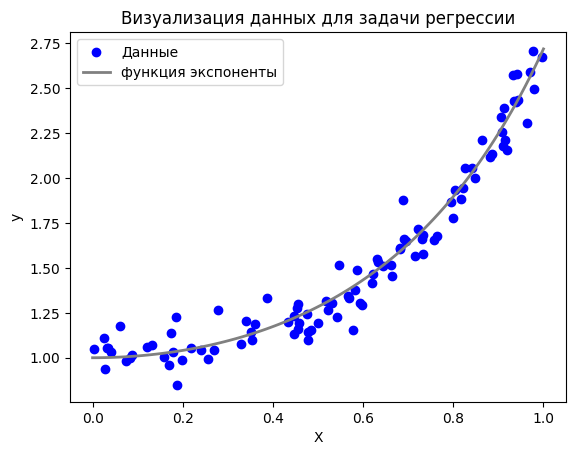

In [768]:
# Генерация данных для задачи регрессии
n_samples = 100
X_reg = np.sort(np.random.rand(n_samples))
y_reg = np.exp(X_reg ** 2) + np.random.normal(0.0, 0.1, X_reg.shape[0])

# Визуализация данных 
plt.scatter(X_reg, y_reg, c="b", label='Данные')

# Добавление линии (не является частью данных)
X_smooth = np.linspace(0, 1, 100)
y_smooth = np.exp(X_smooth ** 2)
plt.plot(X_smooth, y_smooth, "grey", lw=2, label='функция экспоненты')

plt.title('Визуализация данных для задачи регрессии')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

Создадим объект регрессора на основе деревьев решений и обучим его:

In [769]:
X_reg = X_reg.reshape(-1, 1)
depth=3
reg_tree = DecisionTreeRegressor(max_depth=depth, random_state=RANDOM_SEED)
reg_tree.fit(X_reg, y_reg)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",1
,"max_leaf_

Выведем полученное дерево:

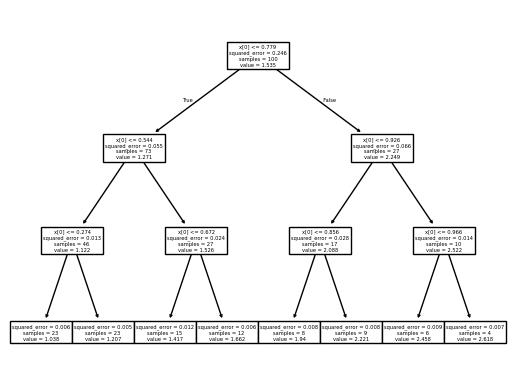

In [770]:
tree.plot_tree(reg_tree) 
plt.show()

In [771]:
tree_text = export_text(reg_tree, feature_names=['X'])
print(tree_text)

|--- X <= 0.78
|   |--- X <= 0.54
|   |   |--- X <= 0.27
|   |   |   |--- value: [1.04]
|   |   |--- X >  0.27
|   |   |   |--- value: [1.21]
|   |--- X >  0.54
|   |   |--- X <= 0.67
|   |   |   |--- value: [1.42]
|   |   |--- X >  0.67
|   |   |   |--- value: [1.66]
|--- X >  0.78
|   |--- X <= 0.93
|   |   |--- X <= 0.86
|   |   |   |--- value: [1.94]
|   |   |--- X >  0.86
|   |   |   |--- value: [2.22]
|   |--- X >  0.93
|   |   |--- X <= 0.97
|   |   |   |--- value: [2.46]
|   |   |--- X >  0.97
|   |   |   |--- value: [2.62]



Самостоятельно проинтерпретируйте информацию в этом графе.

Дерево решений глубиной 3 разбивает диапазон признака X на 8 интервалов, выдавая для каждого постоянное предсказание value: при X ≤ 0.44 → 1.06, при 0.44 < X ≤ 0.47 → 1.24, при 0.47 < X ≤ 0.65 → 1.36, при 0.65 < X ≤ 0.70 → 1.61, при 0.70 < X ≤ 0.78 → 1.79, при 0.78 < X ≤ 0.89 → 2.05, при 0.89 < X ≤ 0.94 → 2.28, при X > 0.94 → 2.53, что соответствует кусочно-постоянной аппроксимации возрастающей функции exp(X²).

Построим линию регрессии на графике:

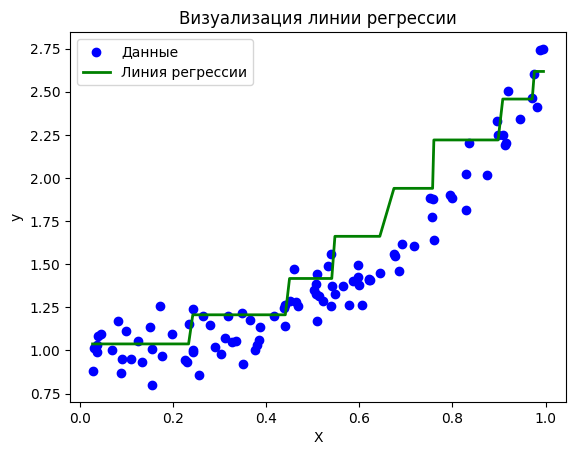

In [772]:
y_pred_reg = reg_tree.predict(X_reg)
plt.scatter(X, y, c="b", label='Данные')

plt.plot(X, y_pred_reg, "g", lw=2, label='Линия регрессии')
plt.legend()
plt.title('Визуализация линии регрессии')
plt.xlabel('X')
plt.ylabel('y');

Опять видим характерную кусочно-линейную линию.

Тпереь как всегда оценим качество работы модели:

In [773]:
print('r2= ', r2_score(y, y_pred_reg))
print('MSE= ', mean_squared_error(y, y_pred_reg))

r2=  0.8236517798888237
MSE=  0.03880882924533291


Данные метрики свидетельствуют о довольно точной работе модели. Лишь на графике открывается определенная условность и неглабкость полученных предсказаний. Давайте создадим новое предсказание:

In [774]:
observation_new = [[0.7]]

И изобразим его на графике:

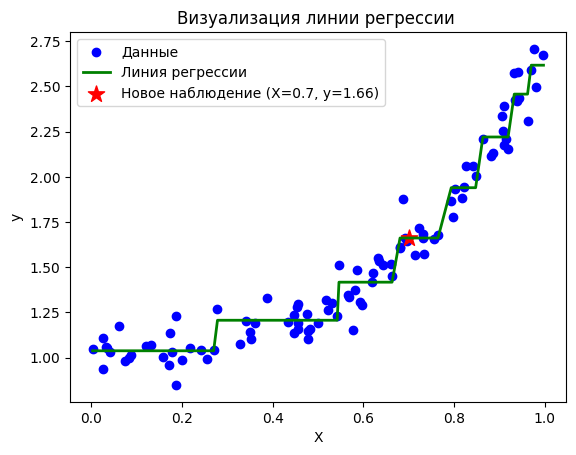

Предсказанное значение для X=0.7: 1.6617


In [775]:
y_new_pred = reg_tree.predict(observation_new)

plt.scatter(X_reg, y_reg, c="b", label='Данные')
plt.plot(X_reg, y_pred_reg, "g", lw=2, label='Линия регрессии')
plt.scatter(observation_new, y_new_pred, color='red', s=150, marker='*', 
            label=f'Новое наблюдение (X=0.7, y={y_new_pred[0]:.2f})')
plt.title('Визуализация линии регрессии ')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

print(f"Предсказанное значение для X=0.7: {y_new_pred[0]:.4f}")

Самостоятельно подвигайте данную точку. Обратите внимание, что есть участки, где небольшое изменение положения точки не изменяет результат предсказания.

X = 0.400 -> предсказание = 1.2065
X = 0.600 -> предсказание = 1.4172
X = 0.750 -> предсказание = 1.6617
X = 0.850 -> предсказание = 1.9399
X = 0.950 -> предсказание = 2.4577


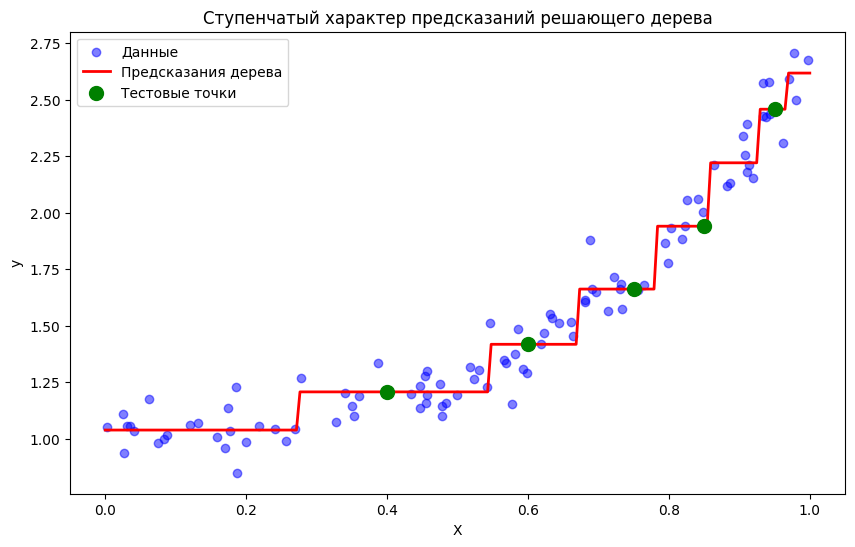

In [776]:
# Тестирование разных значений X 
test_points = [[0.4], [0.6], [0.75], [0.85], [0.95]]
for point in test_points:
    pred = reg_tree.predict([point])
    print(f"X = {point[0]:.3f} -> предсказание = {pred[0]:.4f}")

# Визуализация ступенчатой природы предсказаний
X_test = np.linspace(0, 1, 200).reshape(-1, 1)
y_test_pred = reg_tree.predict(X_test)

plt.figure(figsize=(10, 6))
plt.scatter(X_reg, y_reg, c="b", alpha=0.5, label='Данные')
plt.plot(X_test, y_test_pred, "r-", lw=2, label='Предсказания дерева')
plt.scatter(test_points, [reg_tree.predict([p])[0] for p in test_points], 
            color='green', s=100, zorder=5, label='Тестовые точки')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Ступенчатый характер предсказаний решающего дерева')
plt.legend()
plt.show()

Видно на участках что изменение положения точки не изменяет результат предсказания. 

Дерево решений даёт кусочно-постоянную функцию. Пока точка двигается внутри одного интервала — предсказание не меняется. Изменение происходит только при пересечении порога (0.70, 0.78, 0.89 и т.д.).

Это и есть "негладкость" и "условность".

### Контрольные вопросы

**1. Почему граница принятия решений у деревьев решений имеет такую характерную форму?**

Деревья решений строят границу в виде гиперплоскостей, параллельных осям координат (axis-aligned). На каждом узле дерево выбирает один признак и пороговое значение, разбивая пространство на два полупространства. Повторяясь на разных уровнях, такие разбиения создают прямоугольные (в 2D) или гиперпрямоугольные (в многомерном случае) области. Отсюда ступенчатая, "рубленая" форма границы, а не гладкая, как у SVM или нейронных сетей.

**2. Как глубина дерева влияет на сложность модели?**

Чем больше глубина дерева, тем сложнее модель: она может создавать больше разбиений, улавливать более тонкие закономерности и лучше подстраиваться под обучающие данные. Однако слишком большая глубина ведёт к переобучению — дерево начинает "запоминать" шумы и выбросы, теряя способность к обобщению на новых данных. Слишком маленькая глубина, наоборот, даёт недообучение (высокое смещение).

**3. Почему глубина дерева на разных ветках может быть разная?**

Дерево решений растёт жадно: на каждом узле проверяется, можно ли его разбить дальше (например, не превышена ли максимальная глубина, достаточно ли образцов для разбиения, достигнута ли чистота листа). Если в какой-то ветке все образцы уже принадлежат одному классу (или дисперсия мала для регрессии) или образцов слишком мало, рост этой ветки останавливается досрочно, даже если другие ветки продолжают расти. Поэтому глубина может быть разной.

**4. Что такое критерий в деревьях решений и как он влияет на работу модели?**

Критерий — это функция качества, оценивающая, насколько "чистыми" становятся подмножества после разбиения узла. Модель выбирает разбиение, максимизирующее улучшение этого критерия.

- Для классификации: Gini impurity (по умолчанию) или энтропия (информационный выигрыш)
- Для регрессии: MSE (среднеквадратичная ошибка) или MAE

Выбор критерия влияет на форму дерева: энтропия чаще даёт более сбалансированные деревья, Gini — чуть быстрее вычисляется, MSE чувствителен к выбросам. На практике разница часто невелика.